## Netflix Viewership Analysis
Teresa Ferrill
March 29, 2026

This project review Netflix Viewership, working with Netflix Top 10 Lists.

-----------------------------------------------------------------------------------------------------------------
For this project, I will be working with Netflix Top 10 Lists. These three datasets contain shows/movies based on viewership and their popularity.    

Through the execution of this project, these ethical considerations will be made:    
>1. Data Transformations  
>2. Data Source
>3. Potential Risks  
>4. Assumptions  
>5. Data Credibility  
>6. Ethical Data Use  
>7. Mitigation    

-----------------------------------------------------------------------------------------------------------------
Datasets:  
>All Weeks Countries Netflix - https://content.bellevue.edu/cst/dsc/640/2024Update/Datasets/all-weeks-countries-netflix.xlsx  
>All Weeks Global Netflix - https://content.bellevue.edu/cst/dsc/640/2024Update/Datasets/all-weeks-global-netflix.xlsx  
>Most Popular Netflix - https://content.bellevue.edu/cst/dsc/640/2024Update/Datasets/most-popular-netflix.xlsx  

Dataset Source:  
>Netflix Global Top 10 - https://top10.netflix.com/  

-----------------------------------------------------------------------------------------------------------------  
This project will revolve around this core message:   

Story:  
>Global audiences are increasingly driving Netflix success  
>Titles that perform well across multiple countries tend to become the most successful shows overall  

Audience:  
>Netflix Content Executives:
>>1. The intended audience for this analysis is Netflix Content Executives responsible for content strategy and marketing investment decisions.  
>>2. These stakeholders are familiar with streaming performance metrics but require clear visual insights to guide strategic planning.
>>3. Therefore, the analysis emphasizes high-level visualizations rather than technical modeling.    

Purpose:  
>Demonstrate that international titles generate strong engagement across regions:  
>>1. The purpose of this analysis is to demonstrate how globally appealing content drives sustained engagement across multiple markets.  
>>2. By analyzing Top 10 performance across countries and globally, the goal is to identify patterns that indicate strong cross-market appeal.  

Call to Action:  
>Netflix should expand marketing investment and development of globally appealing content that resonates across multiple countries:
>>1. Based on the analysis, Netflix should increase investment in marketing and development of globally appealing content that performs well across multiple countries.
>>2. Titles that achieve cross-country success demonstrate sustained audience engagement and represent strong candidates for expanded promotion and international distribution strategies.  

Presentation will answer this executive question:  
>*Where should Netflix invest marketing resources to maximize global audience growth?*

Medium:  
>PowerPoint Presentation:
>>1. The analysis will be presented as a PowerPoint presentation designed for executive decision-makers.
>>2. PowerPoint allows visual storytelling through structured slides, making it easier to highlight key insights and recommendations.  

>Design  
>>1. Color - Consistent color schemes help to maintain visual clarity  
>>2. Text - Titles summarize the key insight from each visualization  
>>3. Alignment - Charts were centered and consistently formatted to improve readability  
>>4. Sizing - Larger charts help highlight the most important findings  
>>5. Spacing - Adequate spacing between elements prevents clutter and improves visual hierarchy

Ethical Considerations:  
>1. Data Transformations - Beyond cleaning title formatting and converting date fields, minimal data transformations were performed
>2. Data Source - Netflix’s publicly available Top 10 dataset
>3. Potential Risks - Country-level comparisons may be influenced by differences in Netflix availability and/or audience size
>4. Assumptions - Weeks in the Top 10 were used as a proxy for sustained popularity
>5. Data Credibility - The datasets were sourced from the official Netflix Top 10 reporting site
>6. Ethical Data Use - No personal or sensitive data exist in the data sets
>7. Mitigation - Transparency is maintained through the documentation of all transformations and assumptions  

-----------------------------------------------------------------------------------------------------------------
Overview:  
>1. This analysis seeks to explore how Netflix titles perform across both global and country-level Top 10 lists.  
>2. Through the examination of global viewing trends, country engagement patterns, and most popular titles overall, this analysis identifies which types of content reverberate across multiple markets.  
>3. The results will suggest that titles appearing in many countries tend to sustain longer engagement and higher viewing levels globally.

-----------------------------------------------------------------------------------------------------------------
Step 1: Load and explore datasets, confirm datsets loaded correctly

In [1]:
# Choose to ignore Excel openpyxl warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
from pathlib import Path

# Define plots
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

This code block prepares the notebook environment.  
>The openpyxl warning has been suppressed so the output stays cleaner.  
>The main libraries have been imported that will be used for data analysis, visualization, and file handling.  

-----------------------------------------------------------------------------------------------------------------
Step 2: import data files

In [2]:
# Import data files
countries_file = "../data/all-weeks-countries-netflix.xlsx"
global_file = "../data/all-weeks-global-netflix.xlsx"
popular_file = "../data/most-popular-netflix.xlsx"

countries = pd.read_excel(countries_file)
global_df = pd.read_excel(global_file)
popular = pd.read_excel(popular_file)

print("Countries shape:", countries.shape)
print("Global shape:", global_df.shape)
print("Popular shape:", popular.shape)

Countries shape: (272260, 8)
Global shape: (5840, 11)
Popular shape: (40, 7)


The three Netflix Excel files have been read into separate DataFrames:  
>1. country-level weekly data  
>2. global weekly data  
>3. most-popular titles  

Listing the shape of each dataset confirms the files have been loaded correctly.  
>The shape shows how many rows and columns are in each dataset.  

-----------------------------------------------------------------------------------------------------------------
Step 3: Inspect column names then normalize naming and build helper functions

In [3]:
print("COUNTRIES COLUMNS")
print(countries.columns.tolist())
print("\nGLOBAL COLUMNS")
print(global_df.columns.tolist())
print("\nPOPULAR COLUMNS")
print(popular.columns.tolist())

COUNTRIES COLUMNS
['country_name', 'country_iso2', 'week', 'category', 'weekly_rank', 'show_title', 'season_title', 'cumulative_weeks_in_top_10']

GLOBAL COLUMNS
['week', 'category', 'weekly_rank', 'show_title', 'season_title', 'weekly_hours_viewed', 'runtime', 'weekly_views', 'cumulative_weeks_in_top_10', 'is_staggered_launch', 'episode_launch_details']

POPULAR COLUMNS
['category', 'rank', 'show_title', 'season_title', 'hours_viewed_first_91_days', 'runtime', 'views_first_91_days']


In [4]:
# Helper functin to normalize columns
def normalize_cols(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    return df

# Normalize column naming
countries = normalize_cols(countries)
global_df = normalize_cols(global_df)
popular = normalize_cols(popular)

# Helper function to search for columns based on candidate names
def find_col(df, candidates, required=True):
    cols_lower = {c.lower(): c for c in df.columns}
    
    # exact lower-case match
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    
    # partial match
    for c in df.columns:
        cl = c.lower()
        for cand in candidates:
            if cand.lower() in cl:
                return c
    
    if required:
        raise ValueError(f"Could not find column. Tried candidates: {candidates}\nAvailable columns: {df.columns.tolist()}")
    return None

This code builds reusable helper functions:  
>1. normalize_cols() removes extra spaces from column headers making the fields easier to reference
>2. find_col() automatically searches for the correct column based on likely candidate names  
-----------------------------------------------------------------------------------------------------------------
Step 4: Detecting important columns across datasets

In [5]:
# Identify important columns in each dataset
#  Countries dataset
country_col = find_col(countries, ["country_name", "country", "country / region", "region"])
countries_title_col = find_col(countries, ["show_title", "title", "series_title", "movie_title", "program_title"])
countries_category_col = find_col(countries, ["category", "type"], required=False)
countries_week_col = find_col(countries, ["week", "week_start", "date"], required=False)
countries_rank_col = find_col(countries, ["weekly_rank", "rank"], required=False)
countries_cumweeks_col = find_col(countries, ["cumulative_weeks_in_top_10", "weeks_in_top_10", "cumulative weeks in top 10"], required=False)

#  Global dataset
global_title_col = find_col(global_df, ["show_title", "title", "series_title", "movie_title", "program_title"])
global_category_col = find_col(global_df, ["category", "type"], required=False)
global_week_col = find_col(global_df, ["week", "week_start", "date"], required=False)
global_rank_col = find_col(global_df, ["weekly_rank", "rank"], required=False)
global_views_col = find_col(global_df, ["views", "weekly_views"], required=False)
global_hours_col = find_col(global_df, ["weekly_hours_viewed", "hours_viewed", "view_hours"], required=False)
global_cumweeks_col = find_col(global_df, ["cumulative_weeks_in_top_10", "weeks_in_top_10", "cumulative weeks in top 10"], required=False)

#  Popular dataset
popular_title_col = find_col(popular, ["show_title", "title", "series_title", "movie_title", "program_title"])
popular_category_col = find_col(popular, ["category", "type"], required=False)
popular_rank_col = find_col(popular, ["rank"], required=False)
popular_views_col = find_col(popular, ["views"], required=False)
popular_hours_col = find_col(popular, ["hours_viewed", "view_hours"], required=False)
popular_cumweeks_col = find_col(popular, ["cumulative_weeks_in_top_10", "weeks_in_top_10", "cumulative weeks in top 10"], required=False)

print("Detected columns:")
print("Countries title:", countries_title_col)
print("Countries country:", country_col)
print("Countries category:", countries_category_col)
print("Countries week:", countries_week_col)
print("Countries rank:", countries_rank_col)
print("Countries cumulative weeks:", countries_cumweeks_col)

print("\nGlobal title:", global_title_col)
print("Global category:", global_category_col)
print("Global week:", global_week_col)
print("Global rank:", global_rank_col)
print("Global views:", global_views_col)
print("Global hours:", global_hours_col)
print("Global cumulative weeks:", global_cumweeks_col)

print("\nPopular title:", popular_title_col)
print("Popular category:", popular_category_col)
print("Popular rank:", popular_rank_col)
print("Popular views:", popular_views_col)
print("Popular hours:", popular_hours_col)
print("Popular cumulative weeks:", popular_cumweeks_col)


Detected columns:
Countries title: show_title
Countries country: country_name
Countries category: category
Countries week: week
Countries rank: weekly_rank
Countries cumulative weeks: cumulative_weeks_in_top_10

Global title: show_title
Global category: category
Global week: week
Global rank: weekly_rank
Global views: weekly_views
Global hours: weekly_hours_viewed
Global cumulative weeks: cumulative_weeks_in_top_10

Popular title: show_title
Popular category: category
Popular rank: rank
Popular views: views_first_91_days
Popular hours: hours_viewed_first_91_days
Popular cumulative weeks: None


This step uses the helper function to locate the main variables needed for analysis in each dataset.    
>1. country-level file - identifies the country, title, category, week, rank, and cumulative weeks    
>2. global file - identifies title, category, week, rank, views, hours viewed, and cumulative weeks      
>3. most-popular file - identifies title, category, rank, views, hours, viewed, and cumulative weeks  
 
-----------------------------------------------------------------------------------------------------------------
Step 5: Data Cleaning

In [6]:
# Data cleaning
def clean_title(series):
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

countries[countries_title_col] = clean_title(countries[countries_title_col])
global_df[global_title_col] = clean_title(global_df[global_title_col])
popular[popular_title_col] = clean_title(popular[popular_title_col])

if countries_week_col:
    countries[countries_week_col] = pd.to_datetime(countries[countries_week_col], errors="coerce")

if global_week_col:
    global_df[global_week_col] = pd.to_datetime(global_df[global_week_col], errors="coerce")

# convert numeric columns if present
for df, cols in [
    (countries, [countries_rank_col, countries_cumweeks_col]),
    (global_df, [global_rank_col, global_views_col, global_hours_col, global_cumweeks_col]),
    (popular, [popular_rank_col, popular_views_col, popular_hours_col, popular_cumweeks_col]),
]:
    for c in cols:
        if c is not None:
            df[c] = pd.to_numeric(df[c], errors="coerce")

This block performs basic data cleaning to support more reliable analysis.  
>1. clean_title() function trims leading or taining spaces and collapses repeated spaces to standardize titles  
>2. week fields are converted to datetime format, supporting trend analysis over time  
>3. numeric fields, including rank, views, hours viewed, and cumulative weeks, are converted using pd.to_numeric()to support correct aggretation

-----------------------------------------------------------------------------------------------------------------
Step 5: Visual 1 - Global Top 10 Activity Over Time

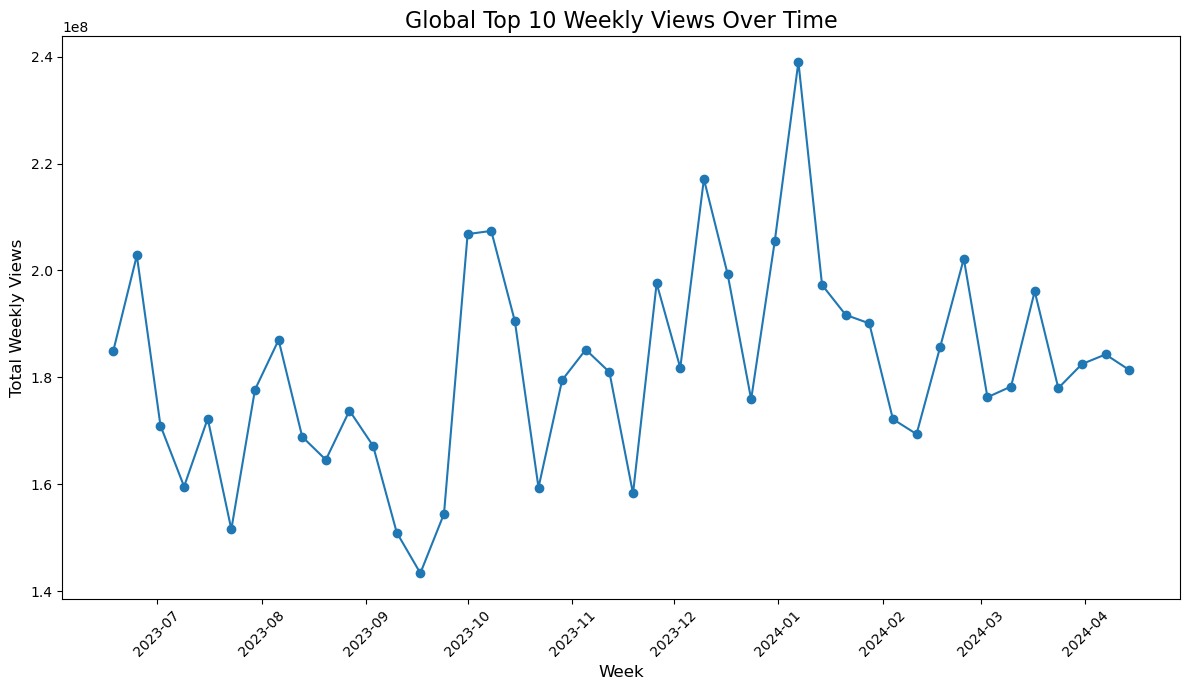

In [7]:
# Visual 1: Global Top 10 activity over time
if global_week_col:
    if global_views_col:
        trend = (
            global_df.groupby(global_week_col)[global_views_col]
            .sum(min_count=1)
            .dropna()
            .sort_index()
        )
        ylabel = "Total Weekly Views"
        title = "Global Top 10 Weekly Views Over Time"

    elif global_hours_col:
        trend = (
            global_df.groupby(global_week_col)[global_hours_col]
            .sum(min_count=1)
            .dropna()
            .sort_index()
        )
        ylabel = "Total Weekly Hours Viewed"
        title = "Global Top 10 Weekly Hours Viewed Over Time"

    else:
        trend = (
            global_df.groupby(global_week_col)[global_title_col]
            .count()
            .sort_index()
        )
        ylabel = "Number of Titles"
        title = "Global Top 10 Title Activity Over Time"

    plt.figure()
    plt.plot(trend.index, trend.values, marker="o")
    plt.title(title)
    plt.xlabel("Week")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("Visual 1 skipped: no week/date column found in the global dataset.")

This is a time-series chart showing global Top 10 activity changes from week-to-week.  
>First, checks are made whether a week column exists  
>Second, the best available metric is selected: weekly views, weekly hours viewed, or title count as a fallback
>Third, grouping by week, summing the selected metric provides the trend line

This visual give a broad performance overview before drilling into individual titles or countries.  

Note: the chart shows a long period of zero values followed by a sharp jump.  This indicates that older rows are missing values in the chosen metric rather than truly representing zero activity.  

-----------------------------------------------------------------------------------------------------------------
Step 6: Visul 2 - Top Titles by Cumulative Weeks in the Global Top 10

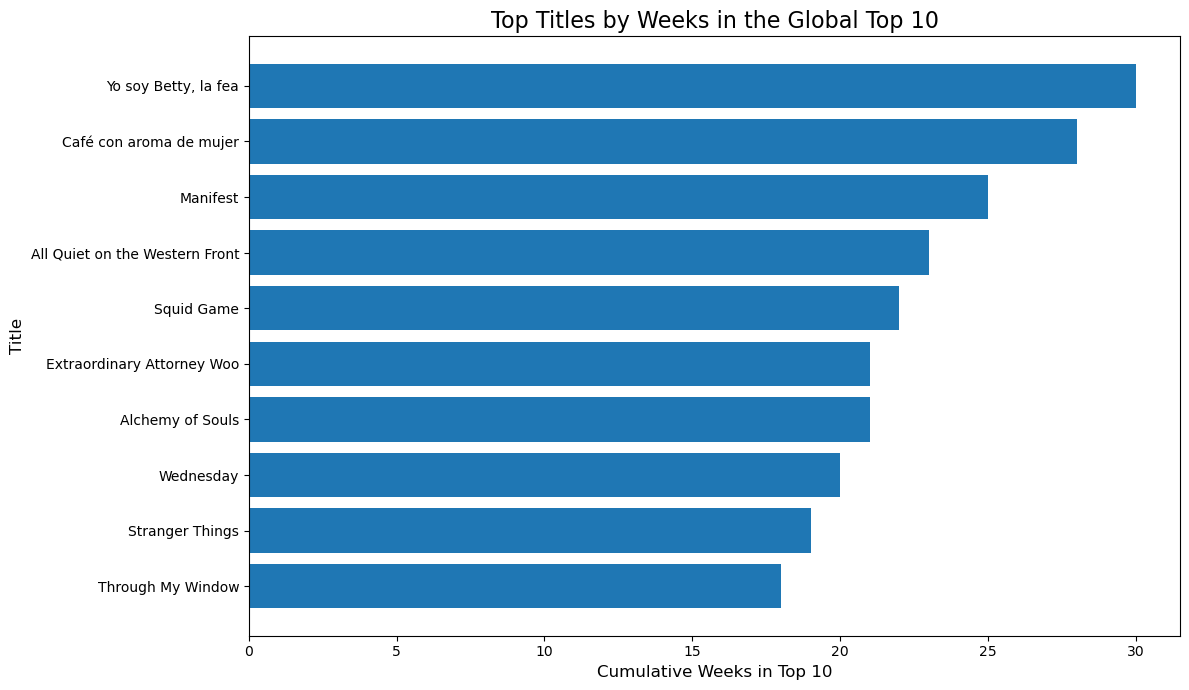

In [8]:
# Visual 2: Top titles by cumulative weeks in the global Top 10
if global_cumweeks_col:
    global_top_weeks = (
        global_df[[global_title_col, global_cumweeks_col]]
        .dropna()
        .groupby(global_title_col, as_index=False)[global_cumweeks_col]
        .max()
        .sort_values(global_cumweeks_col, ascending=False)
        .head(10)
    )

    plt.figure()
    plt.barh(global_top_weeks[global_title_col][::-1], global_top_weeks[global_cumweeks_col][::-1])
    plt.title("Top Titles by Weeks in the Global Top 10")
    plt.xlabel("Cumulative Weeks in Top 10")
    plt.ylabel("Title")
    plt.tight_layout()    
    plt.show()
else:
    # fallback using row counts by title
    global_top_weeks = (
        global_df.groupby(global_title_col)
        .size()
        .reset_index(name="appearance_count")
        .sort_values("appearance_count", ascending=False)
        .head(10)
    )

    plt.figure()
    plt.barh(global_top_weeks[global_title_col][::-1], global_top_weeks["appearance_count"][::-1])
    plt.title("Top Titles by Global Top 10 Appearances")
    plt.xlabel("Number of Appearances")
    plt.ylabel("Title")
    plt.tight_layout()   
    plt.show()

This is horizontal bar graph identifying which titles stayed in the global Top 10 the longest.  
>If the cumulative-weeks column is available, the code groups by title  
>If the cumulative-weeks column is unavailable, the number of appearances by title is counted

This is a strong measure of sustained populatity as it focuses on titles that remained relevant over multiple weeks rather than just those with one-time spikes.   

-----------------------------------------------------------------------------------------------------------------
Step 7: Visual 3 - Countries with the Highest Top 10 Activity

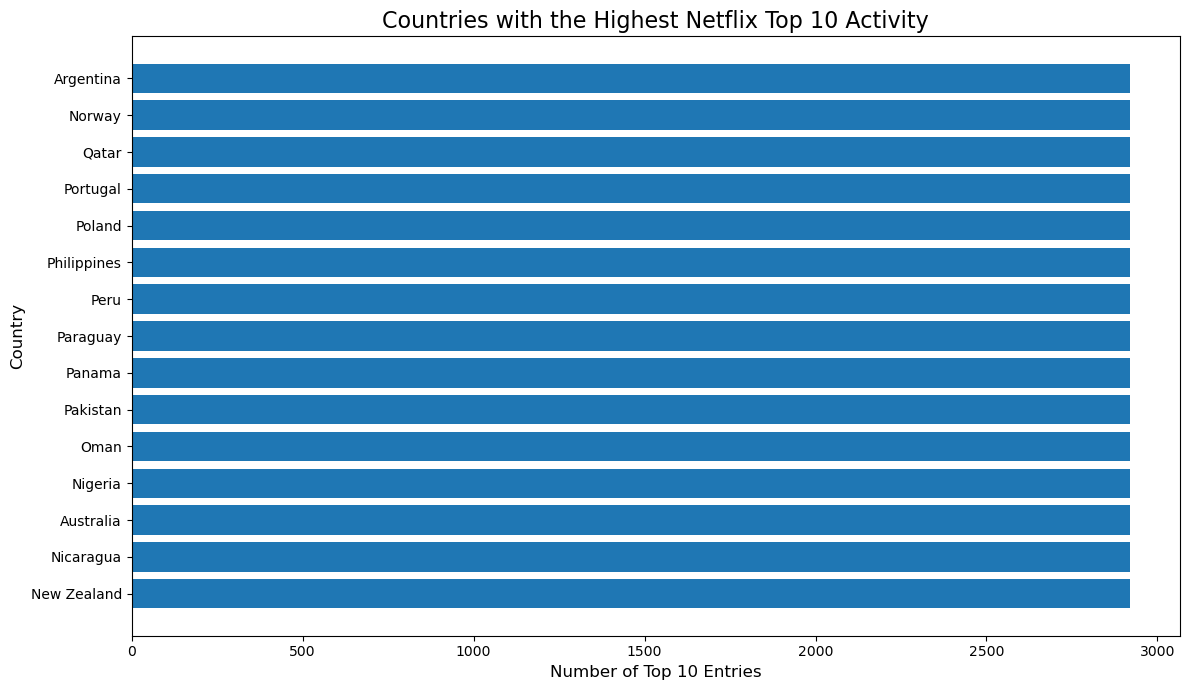

In [9]:
# Visual 3: Countries with the highest Top 10 activity
country_activity = (
    countries.groupby(country_col)
    .size()
    .reset_index(name="top10_entries")
    .sort_values("top10_entries", ascending=False)
    .head(15)
)

plt.figure()
plt.barh(country_activity[country_col][::-1], country_activity["top10_entries"][::-1])
plt.title("Countries with the Highest Netflix Top 10 Activity")
plt.xlabel("Number of Top 10 Entries")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

This horizontal bar chart groups the country-level dataset by country and counts how many Top 10 entries each country has then plots the top 15 countries.  
>This help identify markets with the heaviest Top 10 participation  
>This helps highlight where Netflix audience activity appears strongest or where the Top 10 list is most conistently populated

Note - several countries show the exact same count, as displayed in the summary table.  This likely reflects equal observation periods rather than any true differences in audience strength.  This means the chart is more than likely about dataset coverage than actual comparative engagmenet.  

-----------------------------------------------------------------------------------------------------------------
Step 8: Visual 4 - Titles Appearing in the Most Countries

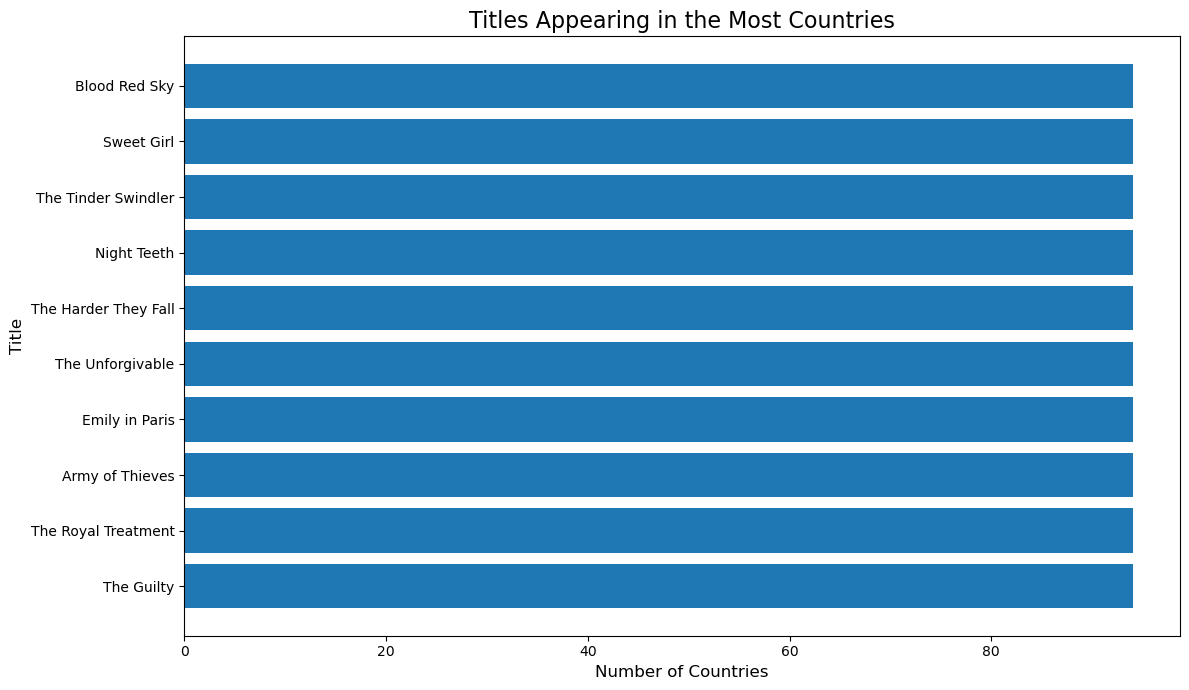

In [10]:
# Visual 4: Titles appearing in the most countries
titles_most_countries = (
    countries.groupby(countries_title_col)[country_col]
    .nunique()
    .reset_index(name="num_countries")
    .sort_values("num_countries", ascending=False)
    .head(10)
)

plt.figure()
wrapped_titles = [textwrap.fill(t, 25) for t in titles_most_countries[countries_title_col]]
plt.barh(wrapped_titles[::-1], titles_most_countries["num_countries"][::-1])
plt.title("Titles Appearing in the Most Countries")
plt.xlabel("Number of Countries")
plt.ylabel("Title")
plt.tight_layout()
plt.show()

This horizontal bar chart measures international reach  
>1. Counts how many unique countries each title appears in
>2. Sorts results and plots the top 10 titles with the broadest country-level presence
>3. Wraps the title text to improve readability for long Netflix names

This is stong visual as it directly supports the question about where Netflix should invest marketing resources to maximize gloval audience growth.  Titles that appear across many countries are likely to have stronger international appeal.   

-----------------------------------------------------------------------------------------------------------------
Step 9: Visual 5 - Film vs TV Performance in the Most-Populat Dataset

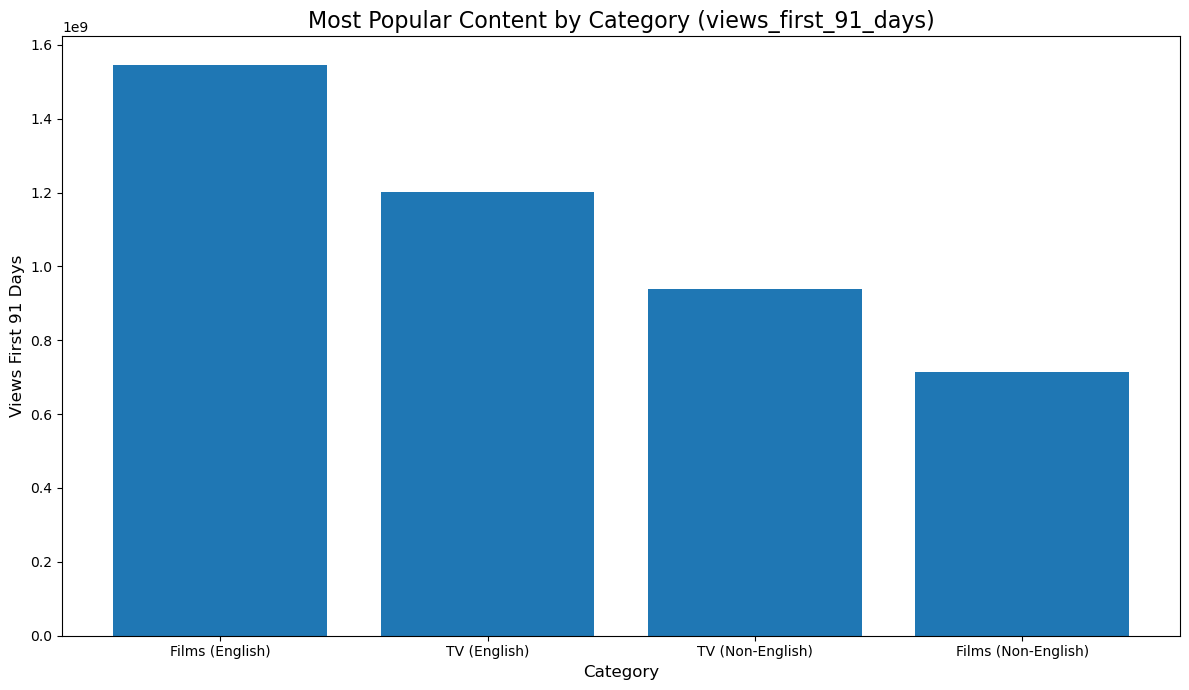

In [11]:
# Visual 5: Film vs TV performance in the Most Popular dataset
if popular_category_col:
    metric_col = popular_views_col if popular_views_col else popular_hours_col if popular_hours_col else popular_cumweeks_col

    if metric_col:
        category_perf = (
            popular.groupby(popular_category_col)[metric_col]
            .sum()
            .reset_index()
            .sort_values(metric_col, ascending=False)
        )

        plt.figure()
        plt.bar(category_perf[popular_category_col], category_perf[metric_col])
        plt.title(f"Most Popular Content by Category ({metric_col})")
        plt.xlabel("Category")
        plt.ylabel(metric_col.replace("_", " ").title())
        plt.tight_layout()        
        plt.show()
    else:
        print("Visual 5 skipped: no metric column found in most popular dataset.")
else:
    print("Visual 5 skipped: no category column found in most popular dataset.")

This bar chart compares content categories using the Most-Popular dataset.  
>1. If a category column exists, either views or hours views is selected as the performance metric  
>2. The metric by category is summed  
>3. The totals are plotted

The goal of this chart is to see whether films or TV series are driving stronger overall performance.  This helps connect content type to audience behavior while giving decision-makers a higher-level view of what kind of programming is generating the strongest results.  

-----------------------------------------------------------------------------------------------------------------
Step 10: Visual 6 - Most Popular Titles Overall

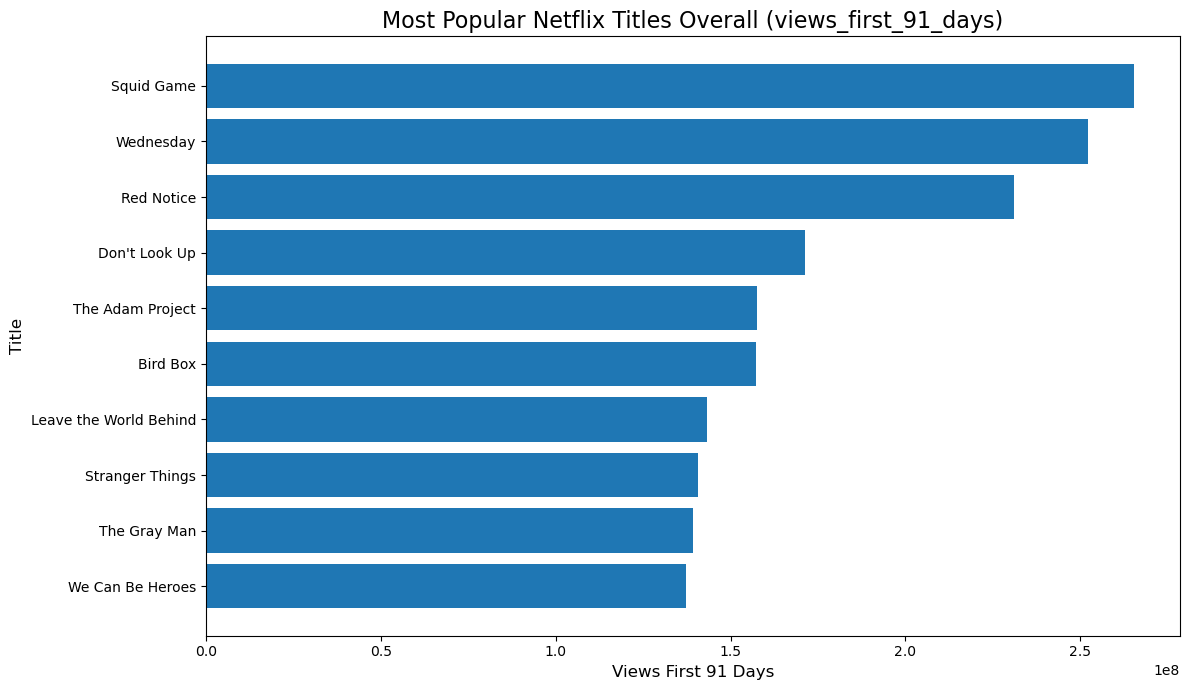

In [12]:
# Visual 6: Most popular titles overall
metric_col = popular_views_col if popular_views_col else popular_hours_col if popular_hours_col else popular_cumweeks_col

if metric_col:
    popular_top_titles = (
        popular[[popular_title_col, metric_col]]
        .dropna()
        .sort_values(metric_col, ascending=False)
        .head(10)
    )

    plt.figure()
    wrapped_titles = [textwrap.fill(t, 25) for t in popular_top_titles[popular_title_col]]
    plt.barh(wrapped_titles[::-1], popular_top_titles[metric_col][::-1])
    plt.title(f"Most Popular Netflix Titles Overall ({metric_col})")
    plt.xlabel(metric_col.replace("_", " ").title())
    plt.ylabel("Title")
    plt.tight_layout()    
    plt.show()
else:
    print("Visual 6 skipped: no suitable popularity metric found.")

This horizontal bar chart ranks the top titles in the Most-Popular dataset using the best available performance metric - either views or hours viewed.  
>1.  missing values are dropped
>2.  values sorted in descending order  
>3.  the top 10 records are kept and visualized
>4.  long titles were wrapped to make the output more presentation-friendly

This chart complements the cumulative-weeks visual as it focuses on top overall popularity instead of sustained weekly presence.  Together, these two visuals distinguish between long-running success and peak populatiry.  

-----------------------------------------------------------------------------------------------------------------
Step 11: Visual 7 - Cross-Market Title Overlap

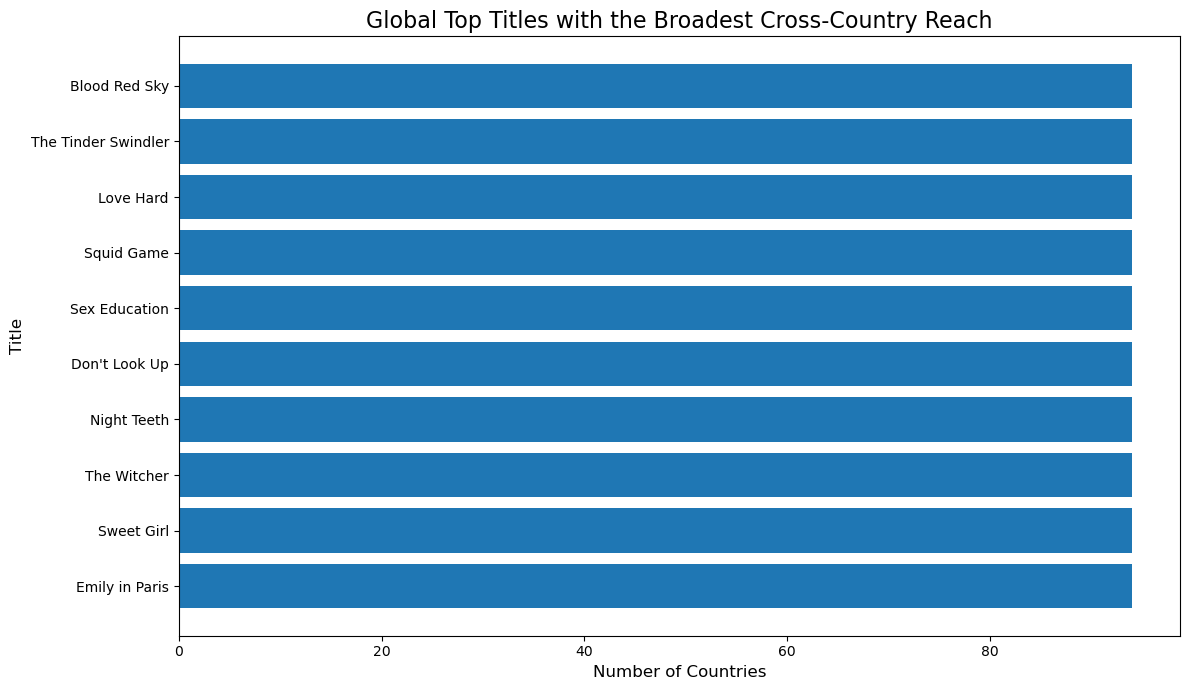

In [13]:
# Visual 7: Cross-Market Title Overlap
global_titles = set(global_df[global_title_col].dropna().unique())
country_spread = (
    countries.groupby(countries_title_col)[country_col]
    .nunique()
    .reset_index(name="num_countries")
)

cross_market = country_spread[country_spread[countries_title_col].isin(global_titles)]
cross_market = cross_market.sort_values("num_countries", ascending=False).head(10)

plt.figure()
wrapped_titles = [textwrap.fill(t, 25) for t in cross_market[countries_title_col]]
plt.barh(wrapped_titles[::-1], cross_market["num_countries"][::-1])
plt.title("Global Top Titles with the Broadest Cross-Country Reach")
plt.xlabel("Number of Countries")
plt.ylabel("Title")
plt.tight_layout()
plt.show()

This horizontal bar chart identifies titles that appear in both the global Top 10 and the country-level Top 10 lists.  They are then ranked by the number of countries in which they appear.  This chart is business-focused and it narrows attention to titles that are both globally recognized and broadly distributed across markets - it highlights the strongest candidates for international promotion and future content investment.  This viausl aligns well with the stated 'call to action.'

-----------------------------------------------------------------------------------------------------------------
Step 12: Summary Tables

In [14]:
# Summary Tables
print("\nTop countries by Top 10 activity:")
display(country_activity.head(10))

print("\nTitles appearing in the most countries:")
display(titles_most_countries.head(10))

print("\nMost popular titles overall:")
if metric_col:
    display(popular_top_titles.head(10))


Top countries by Top 10 activity:


,country_name,top10_entries
0,Argentina,2920
59,Norway,2920
68,Qatar,2920
67,Portugal,2920
66,Poland,2920
65,Philippines,2920
64,Peru,2920
63,Paraguay,2920
62,Panama,2920
61,Pakistan,2920



Titles appearing in the most countries:


,show_title,num_countries
828,Blood Red Sky,94
5205,Sweet Girl,94
6319,The Tinder Swindler,94
3927,Night Teeth,94
5749,The Harder They Fall,94
6352,The Unforgivable,94
1678,Emily in Paris,94
480,Army of Thieves,94
6202,The Royal Treatment,94
5740,The Guilty,94



Most popular titles overall:


,show_title,views_first_91_days
30,Squid Game,265200000
20,Wednesday,252100000
0,Red Notice,230900000
1,Don't Look Up,171400000
2,The Adam Project,157600000
3,Bird Box,157400000
4,Leave the World Behind,143400000
21,Stranger Things,140700000
5,The Gray Man,139300000
6,We Can Be Heroes,137300000


These summary tables identify the top countries by  
>1. Top 10 activity
>2. Titles appearing in most countries
>3. Most popular titles overall

These summaries help to validate that the visuals match the underlying data.  

-----------------------------------------------------------------------------------------------------------------
Step 13: Summary and Review

This analysis explored Netflix Top 10 performance across global and country-level datasets to better understand how content performs across different markets.  The goal was not just to examine trends, but to answer a business-driven question: where Netflix should focus marketing and content investment to maximize global audience growth.  This approach supports decision-making rather than simply reporting findings, which aligns with best practices in data storytelling (Knaflic, 2015).  

From a data perspective, the workflow followed a structured approach.  The datasets were first validated and cleaned, including standardizing titles, converting date fields, and ensuring numeric values were properly formatted.  Helper functions were used to dynamically identify key columns, which made the analysis more flexible and reusable.  This step was important because the datasets did not always follow consistent naming conventions, and handling that variability upfront improved the reliability of the results (Kuhn & Johnson, 2019).  

The visualizations move from broad trends into more detailed insights.  The global time-series chart gives a good overall view of engagement over time, but it also points out a limitation - some of the earlier values may be missing data rather than true zero activity.  From there, the analysis shifted to identifying titles with sustained success using cumulative weeks in the Top 10.  This helped distinguish between short-term popularity and long-term audience engagement, which is critical when evaluating performance trends over time (Cairo, 2016).  

One of the most meaningful findings came from examining cross-country performance.  Titles that appeared in multiple countries consistently showed stronger and more sustained engagement.  This pattern suggests - when considering marketing and distribution strategies - that globally appealing content has a higher return on investment.  The cross-market overlap visualization reinforced this insight by highlighting titles that performed well both globally and across multiple countries, supporting the idea that well-designed visuals can reveal patterns not immediately obvious in raw data (Knaflic, 2015).  

There are a few limitations worth noting:  
>1. Country-level comparisons may reflect differences in Netflix availability, audience size, or data coverage rather than true engagement levels.   
>2. Using 'weeks in the Top 10' as a measure of popularity assumes that longer visibility means stronger audience interest.  This may not always be the case.  
>>*This metric does not capture all aspects of viewing behavior.*  

These considerations help keep the analysis transparent and reduce the risk of misinterpretation (Cairo, 2016).  

Overall, this projects results point to a clear recommendation: Netflix should focus on investing in content that performs well across multiple markets.  Titles with broad international reach are more likely to maintain engagement and support long-term growth.  This analysis provides solid directional insight; however, it could be strengthened by incorporating additional metrics, including audience demographics or viewing duration.  This will provide a more complete picture of performance (Kuhn & Johnson, 2019).  

This project demonstrates how data visualization can move beyond reporting and instead support strategic decision-making when paired with clear storytelling and thoughtful interpretation.  

References:  
Cairo, A. (2016). The truthful art: Data, charts, and maps for communication. New Riders.  

Knaflic, C. N. (2015). Storytelling with data: A data visualization guide for business professionals. Wiley.  

Kuhn, M., & Johnson, K. (2019). Feature engineering and selection: A practical approach for predictive models. CRC Press.  